# Two-element interferometer with an extended source

This notebook extends the point-source model in `two_element_interferometer.ipynb` to an
**arbitrary sky brightness distribution** `I(l, m)`, where `l, m` are small direction cosines
(tangent-plane sky coordinates, in radians) measured from the field centre.

Approach:

1. Define the source brightness `I(l, m)` on a small grid (a few built-in generators are
   provided: Gaussian, disk, double point source — or supply your own array).
2. Because the field is assumed small, the complex visibility is simply the 2-D Fourier
   transform of the brightness distribution:

$$ V(u, v) = \iint I(l, m)\, e^{-2\pi i (ul + vm)}\, dl\, dm $$

   computed once on a regular `(u, v)` grid via an FFT.
3. As the Earth rotates, the two antennas (assumed to track the source perfectly) sample a
   changing physical baseline `(u(t), v(t))`, in wavelengths. The complex visibility at each
   time is obtained by **interpolating** the FFT grid at that `(u(t), v(t))` point.

Because the antennas track the source, there is no primary-beam attenuation or bandwidth
smearing to model here — we go directly from source structure to the observed visibility
amplitude and phase versus time.

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

import astropy.coordinates as coord
import astropy.units as u
import astropy.constants as constants
from astropy.time import Time, TimeDelta

## 1. Sky-plane source grid and brightness distributions

`build_sky_grid` lays out a small `(l, m)` patch of sky. The generator functions below fill in
an intensity value at each grid point; you can also just build your own 2-D array of the same
shape.

In [ ]:
def build_sky_grid(fov, npix):
    """
    Build a square (l, m) tangent-plane grid.

    Parameters
    ----------
    fov : astropy.units.Quantity (angle)
        Full width of the field of view.
    npix : int
        Number of pixels per side.

    Returns
    -------
    l, m : ndarray, shape (npix, npix)
        Direction cosines (radians).
    dl : float
        Pixel scale (radians).
    """
    fov_rad = fov.to(u.rad).value
    dl = fov_rad / npix
    axis = (np.arange(npix) - npix // 2) * dl
    l, m = np.meshgrid(axis, axis, indexing="xy")
    return l, m, dl


def gaussian_source(l, m, fwhm, l0=0.0 * u.rad, m0=0.0 * u.rad, flux=1.0*u.Jy):
    """Circular Gaussian brightness distribution of the given FWHM (angle)."""
    sigma = fwhm.to(u.rad).value / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    r2 = (l - l0.to(u.rad).value) ** 2 + (m - m0.to(u.rad).value) ** 2
    ret = np.exp(-r2 / (2.0 * sigma ** 2))
    dl=(l[0, 1] - l[0, 0])*u.rad  # Assuming uniform grid spacing
    normalisation = np.sum(ret)*dl**2 / flux
    return ret / normalisation



def disk_source(l, m, radius, l0=0.0 * u.rad, m0=0.0 * u.rad, flux=1.0*u.Jy):
    """Uniform-brightness disk of the given angular radius."""
    radius_rad = radius.to(u.rad).value
    r = np.sqrt((l - l0.to(u.rad).value) ** 2 + (m - m0.to(u.rad).value) ** 2)
    ret =  (r <= radius_rad).astype(float)
    dl=(l[0, 1] - l[0, 0])*u.rad  # Assuming uniform grid spacing
    normalisation = np.sum(ret)*dl**2 / flux
    return ret / normalisation


def double_point_source(l, m, dl, separation, flux_ratio=1.0, point_fwhm=None):
    """Two closely-spaced point-like sources, separated along the l axis."""
    if point_fwhm is None:
        point_fwhm = 2.0 * dl * u.rad
    half_sep = separation.to(u.rad).value / 2.0
    src_1 = gaussian_source(l, m, point_fwhm, l0=-half_sep * u.rad, flux=1.0*u.Jy)
    src_2 = gaussian_source(l, m, point_fwhm, l0=+half_sep * u.rad, flux=flux_ratio*u.Jy)
    return src_1 + src_2

def double_gaussian_source(l, m, separation, fwhm, flux_ratio=1.0):
    """Two closely-spaced Gaussian sources, separated along the l axis."""
    half_sep = separation.to(u.rad).value / 2.0
    src_1 = gaussian_source(l, m, fwhm, l0=-half_sep * u.rad, flux=1.0*u.Jy)
    src_2 = gaussian_source(l, m, fwhm, l0=+half_sep * u.rad, flux=flux_ratio*u.Jy)
    return src_1 + src_2

def gaussian_ring_source(l, m, radius, fwhm, l0=0.0 * u.rad, m0=0.0 * u.rad, flux=1.0*u.Jy):
    """Ring source with a radial Gaussian profile of given FWHM centered at given radius."""
    sigma = fwhm.to(u.rad).value / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    radius_rad = radius.to(u.rad).value
    r = np.sqrt((l - l0.to(u.rad).value) ** 2 + (m - m0.to(u.rad).value) ** 2)
    ret= np.exp(-((r - radius_rad) ** 2) / (2.0 * sigma**2))
    dl=(l[0, 1] - l[0, 0])*u.rad  # Assuming uniform grid spacing
    normalisation = np.sum(ret)*dl**2 / flux
    return ret / normalisation

def radio_galaxy_source(
    l,
    m,
    separation,
    lobe_fwhm,
    core_fwhm,
    l0=0.0 * u.rad,
    m0=0.0 * u.rad,
    core_flux=0.2*u.Jy,
    lobe_flux_ratio=1.0,
    pa=0.0 * u.deg,
):
    """
    Cygnus A-like source: central core + two extended Gaussian lobes.
    
    Parameters
    ----------
    separation : Quantity
        Angular distance between the two lobes.
    lobe_fwhm : Quantity
        FWHM size of the extended lobes.
    core_fwhm : Quantity
        FWHM size of the central core point source.
    pa : Quantity, optional
        Position Angle of the jet axis measured East of North (or relative to m-axis).
    """
    pa_rad = pa.to(u.rad).value
    half_sep = (separation / 2.0).to(u.rad).value

    # Position offsets for lobes based on position angle
    dl_lobe = half_sep * np.sin(pa_rad)
    dm_lobe = half_sep * np.cos(pa_rad)

    # Central Core
    core = gaussian_source(l, m, core_fwhm, l0=l0, m0=m0, flux=core_flux)

    # Lobe 1 (+ position angle direction)
    lobe1 = gaussian_source(
        l,
        m,
        lobe_fwhm,
        l0=l0 + dl_lobe * u.rad,
        m0=m0 + dm_lobe * u.rad,
        flux=1.0,
    )

    # Lobe 2 (- position angle direction)
    lobe2 = gaussian_source(
        l,
        m,
        lobe_fwhm,
        l0=l0 - dl_lobe * u.rad,
        m0=m0 - dm_lobe * u.rad,
        flux=lobe_flux_ratio,
    )

    return core + lobe1 + lobe2



## 2. FFT visibility of the source distribution

The FFT of `I(l, m)` gives `V(u, v)` on a regular grid whose spacing is set by the field of view
and pixel scale. We normalise `V` by the total flux so that `V(0, 0) = 1`, and build an
interpolator so `V` can be evaluated at any `(u, v)` within the sampled range.

In [ ]:
def compute_source_visibility(intensity, dl,pad_factor=4):
    """
    Fourier transform a source brightness distribution to get V(u, v).

    Parameters
    ----------
    intensity : ndarray, shape (npix, npix)
        Sky brightness on the (l, m) grid from `build_sky_grid`, in Jy/steradian.
    dl : float
        Pixel scale of the (l, m) grid (radians).

    Returns
    -------
    u_axis, v_axis : ndarray
        1-D (u, v) axes of the visibility grid (wavelengths).
    V_grid : ndarray, complex
        Complex visibility on the (v_axis, u_axis) grid in Jy.
    visibility_at : callable
        visibility_at(u, v) -> interpolated complex visibility.
    """

    npix = intensity.shape[0]
    padded_npix = npix * pad_factor
    pad_width = (padded_npix - npix) // 2
    padded_intensity = np.pad(intensity, pad_width, mode="constant",constant_values=0.0).to(u.Jy/u.steradian).value

    V_grid = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(padded_intensity)))*dl**2

    

    freqs = np.fft.fftshift(np.fft.fftfreq(padded_npix, d=dl))
    u_axis, v_axis = freqs, freqs

    real_interp = RegularGridInterpolator(
        (v_axis, u_axis), V_grid.real, bounds_error=False, fill_value=0.0
    )
    imag_interp = RegularGridInterpolator(
        (v_axis, u_axis), V_grid.imag, bounds_error=False, fill_value=0.0
    )

    def visibility_at(u_query, v_query):
        points = np.stack(
            [np.atleast_1d(v_query), np.atleast_1d(u_query)], axis=-1
        )
        return real_interp(points) + 1j * imag_interp(points)

    return u_axis, v_axis, V_grid, visibility_at

## 3. The (u, v) track from the antenna geometry

The antennas are assumed to track the source perfectly, so there is no beam pointing offset to
compute. The baseline vector is fixed in the Earth-fixed (ITRS) frame; as the source's Greenwich
hour angle `H = GST - RA` changes through the observation, the projection of the baseline onto
the plane perpendicular to the source direction traces out the classical `(u, v)` ellipse:

$$
\begin{aligned}
u &= \sin H \, B_x + \cos H \, B_y \\
v &= -\sin\delta \cos H \, B_x + \sin\delta \sin H \, B_y + \cos\delta \, B_z
\end{aligned}
$$

with `(u, v)` expressed in wavelengths by dividing through by the observing wavelength.

In [113]:
def compute_baseline_uvw(
    antenna_A,
    antenna_B,
    source,
    frequency,
    reference_date,
    hours_from_transit=0.5,
    observation_length=2 * u.hour,
    observation_steps=2000,
    verbose=True,
):
    """Compute the (u, v, w) track of a baseline in wavelengths as the Earth rotates."""

    baseline_vector = (
        antenna_B.get_itrs().cartesian - antenna_A.get_itrs().cartesian
    ).xyz
    baseline_length = np.linalg.norm(baseline_vector)
    wavelength = (constants.c.si / frequency).to(u.m)

    if verbose:
        print(f"Baseline length = {baseline_length:.3f}")
        print(f"Observing wavelength = {wavelength:.4f}")
        print(
            f"Baseline = {(baseline_length / wavelength).decompose():.2f} wavelengths"
        )

    # Transit time, found via the local (antenna A) sidereal time, as in the point-source notebook.
    sidereal_rate = 1.0027379093604878
    hour_angle_ref = (
        reference_date.sidereal_time("mean", longitude=antenna_A.lon) - source.ra
    ).wrap_at(180 * u.deg)
    transit_time = reference_date - TimeDelta(
        (hour_angle_ref.hour * u.hour / sidereal_rate).to(u.s)
    )

    observation_centre_time = transit_time + TimeDelta(hours_from_transit * u.hour)
    time_steps = (
        np.arange(
            -observation_length.to(u.s).value / 2,
            observation_length.to(u.s).value / 2,
            observation_length.to(u.s).value / observation_steps,
        )
        * u.s
    )
    times = observation_centre_time + TimeDelta(time_steps)
    transit_hours = (times - transit_time).to(u.hour).value

    if verbose:
        print(f"Transit time = {transit_time.iso}")
        print(f"Observation centre time = {observation_centre_time.iso}")

    # Greenwich hour angle and declination of the source at each time.
    gst = times.sidereal_time("mean", longitude=0 * u.deg)
    hour_angle = (gst - source.ra).radian
    dec = source.dec.radian

    Bx, By, Bz = baseline_vector

    u_phys = np.sin(hour_angle) * Bx + np.cos(hour_angle) * By
    v_phys = (
        -np.sin(dec) * np.cos(hour_angle) * Bx
        + np.sin(dec) * np.sin(hour_angle) * By
        + np.cos(dec) * Bz
    )
    w_phys = (
        np.cos(dec) * np.cos(hour_angle) * Bx
        - np.cos(dec) * np.sin(hour_angle) * By
        + np.sin(dec) * Bz
    )

    u_wave = (u_phys / wavelength).decompose().value
    v_wave = (v_phys / wavelength).decompose().value
    w_wave = (w_phys / wavelength).decompose().value

    return {
        "baseline_length": baseline_length,
        "times": times,
        "transit_time": transit_time,
        "transit_hours": transit_hours,
        "u": u_wave,
        "v": v_wave,
        "w": w_wave,
    }

## 4. Putting it together

`simulate_extended_source_interferometer` ties the FFT visibility (step 2) to the (u, v) track
(step 3), and plots the source map, the sampled `|V(u, v)|` plane, and the resulting visibility
amplitude and phase versus time.

In [114]:
def simulate_extended_source_interferometer(
    antenna_A,
    antenna_B,
    source,
    frequency,
    intensity,
    dl,
    reference_date,
    hours_from_transit=0.0,
    observation_length=12 * u.hour,
    observation_steps=2000,
    pad_factor=4,
    verbose=True,
    plot=True,
    log_intensity=False
):
    """Simulate a two-element interferometer observing an extended source."""

    u_axis, v_axis, V_grid, visibility_at = compute_source_visibility(intensity, dl, pad_factor=pad_factor)

    uvw = compute_baseline_uvw(
        antenna_A,
        antenna_B,
        source,
        frequency,
        reference_date,
        hours_from_transit=hours_from_transit,
        observation_length=observation_length,
        observation_steps=observation_steps,
        verbose=verbose,
    )
    u_t, v_t = uvw["u"], uvw["v"]

    # The FFT grid only samples (u, v) out to its Nyquist limit.
    nyquist = u_axis.max()
    max_uv = max(np.abs(u_t).max(), np.abs(v_t).max())
    if verbose and max_uv > nyquist:
        print(
            f"WARNING: baseline reaches {max_uv:.1f} wavelengths, "
            f"beyond the sampled (u, v) grid (max {nyquist:.1f}). "
            "Increase npix or reduce the field of view."
        )

    visibility = visibility_at(u_t, v_t)
    visibility_amplitude = np.abs(visibility)
    visibility_phase = np.unwrap(np.angle(visibility))
    
    intensity_jy = intensity.to(u.Jy/u.steradian).value
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        (ax1, ax2), (ax3, ax4) = axes

        npix = intensity_jy.shape[0]
        l_extent = ((np.arange(npix) - npix // 2) * dl * u.rad).to(u.arcsec).value
        if log_intensity:
            intensity_jy = np.log10(intensity_jy + 1e-9 * intensity.max())
            ax1.set_title("Log10 Source brightness I(l, m)")
        else:
            ax1.set_title("Source brightness I(l, m)")
        ax1.imshow(
            intensity_jy,
            origin="lower",
            extent=[l_extent[0], l_extent[-1], l_extent[0], l_extent[-1]],
            cmap="inferno",
        )
        ax1.set_xlabel("l [arcsec]")
        ax1.set_ylabel("m [arcsec]")

        ax2.imshow(
            np.abs(V_grid),
            origin="lower",
            extent=[u_axis[0], u_axis[-1], v_axis[0], v_axis[-1]],
            cmap="viridis",
        )
        ax2.plot(u_t, v_t, color="w", lw=2.0)
        u_limit = 2 * np.max(np.abs(u_t))
        v_limit = 2 * np.max(np.abs(v_t))
        limit=np.max([u_limit, v_limit])

        ax2.set_xlim(-limit, limit)
        ax2.set_ylim(-limit, limit)
        ax2.set_xlabel("u [wavelengths]")
        ax2.set_ylabel("v [wavelengths]")
        ax2.set_title("|V(u, v)| with sampled track")

        visibility_phase_wrapped = np.angle(np.exp(1j * visibility_phase))
        visibility_phase_wrapped[visibility_phase_wrapped > 0.99*np.pi] -= 2 * np.pi

        amp_color = "tab:blue"
        phase_color = "tab:red"

        ax3.plot(uvw["transit_hours"], visibility_amplitude, lw=1.2, color=amp_color)
        ax3.set_xlabel("Hours from source transit")
        ax3.set_ylabel("Visibility amplitude (Jy)", color=amp_color)
        ax3.tick_params(axis="y", labelcolor=amp_color)
        ax3.set_title("Visibility amplitude & phase vs. time")
        ax3.grid(True, alpha=0.3)

        ax3b = ax3.twinx()
        ax3b.plot(uvw["transit_hours"], visibility_phase_wrapped, lw=1.2, color=phase_color,alpha=0.5)
        ax3b.set_ylabel("Visibility phase [rad]", color=phase_color)
        ax3b.tick_params(axis="y", labelcolor=phase_color)
        ax3b.set_ylim(-np.pi, np.pi)

        # Direct slice of the u-v plane at v = 0, out to the longest projected baseline
        uv_radius_max = np.max(np.sqrt(u_t ** 2 + v_t ** 2))
        u_slice = np.linspace(0.0, uv_radius_max, 1000)
        slice_visibility = visibility_at(u_slice, np.zeros_like(u_slice))
        slice_amplitude = np.abs(slice_visibility)
        slice_phase = np.angle(slice_visibility)
        # Stop the phase from jumping by 2pi at the wrap point, for plotting purposes.
        slice_phase[slice_phase > 0.99*np.pi] -= 2 * np.pi

        ax4.plot(u_slice, slice_amplitude, lw=1.2, color=amp_color)
        ax4.set_xlabel("Baseline length u at v = 0 [wavelengths]")
        ax4.set_ylabel("Visibility amplitude (Jy)", color=amp_color)
        ax4.tick_params(axis="y", labelcolor=amp_color)
        ax4.set_title("Visibility amplitude & phase vs. baseline length (v = 0 slice)")
        ax4.set_ylim(0, max(np.max(visibility_amplitude), np.max(slice_amplitude)))
        ax3.set_ylim(0, max(np.max(visibility_amplitude), np.max(slice_amplitude)))

        ax4.set_xlim(0, uv_radius_max)
        ax4.grid(True, alpha=0.3)

        ax4b = ax4.twinx()
        ax4b.plot(u_slice, slice_phase, lw=1.2, color=phase_color,alpha=0.5)
        ax4b.set_ylabel("Visibility phase [rad]", color=phase_color)
        ax4b.tick_params(axis="y", labelcolor=phase_color)
        ax4b.set_ylim(-np.pi, np.pi)

        plt.tight_layout()
        plt.show()

    return {
        "u_axis": u_axis,
        "v_axis": v_axis,
        "V_grid": V_grid,
        "u": u_t,
        "v": v_t,
        "transit_hours": uvw["transit_hours"],
        "visibility": visibility,
        "visibility_amplitude": visibility_amplitude,
        "visibility_phase": visibility_phase,
    }


In [115]:
def make_antenna_pair(lat, lon, baseline, orientation):
    """
    Create a pair of antennas separated by a given baseline length and orientation.

    Parameters
    ----------
    lat : astropy.units.Quantity (angle)
        Latitude of the first antenna.
    lon : astropy.units.Quantity (angle)
        Longitude of the first antenna.
    baseline : astropy.units.Quantity (length)
        Baseline length between the two antennas.
    orientation : astropy.units.Quantity (angle)
        Orientation of the baseline relative to North (0 degrees).

    Returns
    -------
    antenna_A, antenna_B : astropy.coordinates.EarthLocation
        Locations of the two antennas.
    """
    # Antenna A at the specified lat/lon
    antenna_A = coord.EarthLocation(lat=lat, lon=lon)

    # Calculate the offset for Antenna B
    delta_north = baseline * np.cos(orientation.to(u.rad).value)
    delta_east = baseline * np.sin(orientation.to(u.rad).value)

    # Convert offsets to degrees
    earth_radius = constants.R_earth

    # Convert dimensionless small-angle ratios explicitly to radians.
    delta_lat = np.arcsin(
        (delta_north / earth_radius).decompose().value
    ) * u.rad
    delta_lon = np.arcsin(
        (delta_east / (earth_radius * np.cos(lat))).decompose().value
    ) * u.rad

    # Antenna B at the offset position
    antenna_B = coord.EarthLocation(
        lat=lat + delta_lat, lon=lon + delta_lon
    )

    return antenna_A, antenna_B

## 5. Example: Gaussian source


Baseline length = 10021.618 m
Observing wavelength = 0.1499 m
Baseline = 66857.04 wavelengths
Transit time = 2026-09-20 10:11:57.293
Observation centre time = 2026-09-20 10:11:57.293


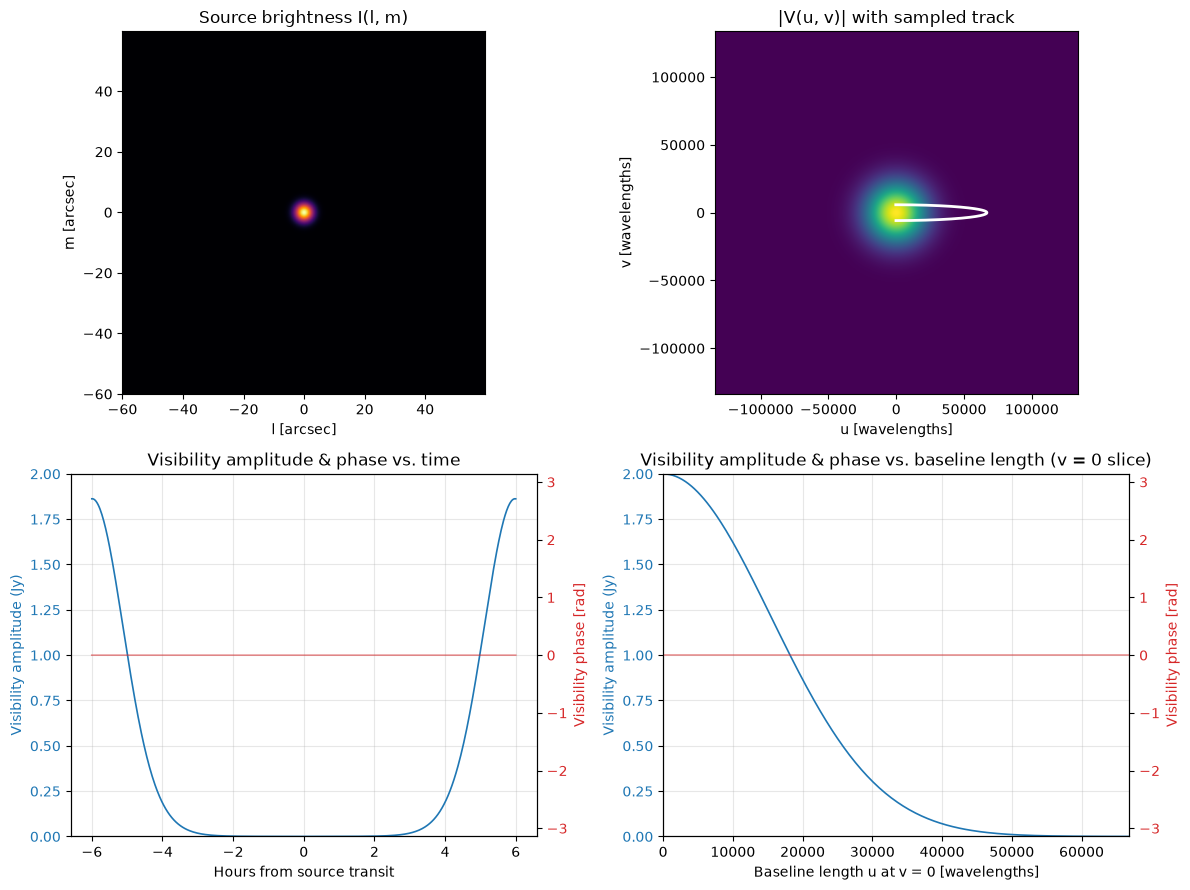

In [116]:

antenna_A, antenna_B = make_antenna_pair(
    lat=53.2365 * u.deg,
    lon=-2.3080 * u.deg,
    baseline=10 * u.km,
    orientation=90 * u.deg, 
)

source = coord.SkyCoord(ra=10.0 * u.hourangle, dec=5. * u.deg, frame="icrs")

frequency = 2000.0 * u.MHz
reference_date = Time("2026-09-20T10:00:00")
hours_from_transit = 0

# Sky-plane grid: field of view must be large enough to resolve the source,
# and fine enough (small enough pixels) to sample the baseline's (u, v) reach.
fov = 120 * u.arcsec
npix = 512

l, m, dl = build_sky_grid(fov, npix)
intensity = gaussian_source(l, m, fwhm=5 * u.arcsec,flux=2.0*u.Jy)

results_gaussian = simulate_extended_source_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    source=source,
    frequency=frequency,
    intensity=intensity,
    dl=dl,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=12 * u.hour,
    observation_steps=8000
)

## 6. Example: disk source

Baseline length = 10021.618 m
Observing wavelength = 0.1499 m
Baseline = 66857.04 wavelengths
Transit time = 2026-09-20 10:11:57.293
Observation centre time = 2026-09-20 10:11:57.293


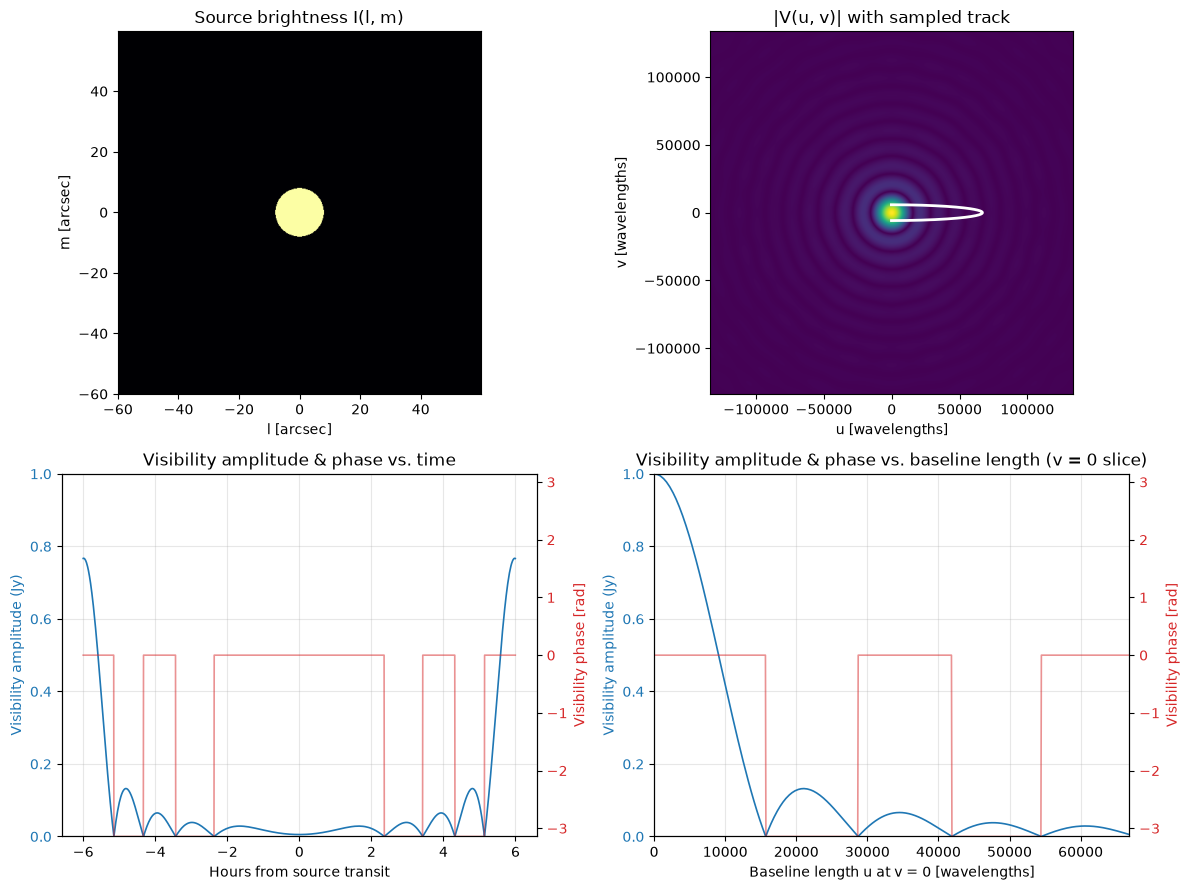

In [117]:
intensity_disk = disk_source(l, m, radius=8 * u.arcsec)

results_disk = simulate_extended_source_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    source=source,
    frequency=frequency,
    intensity=intensity_disk,
    dl=dl,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=12 * u.hour,
    observation_steps=2000,
)

## 7. Example: double point source

A resolved pair of point sources shows up as fringes in the visibility amplitude as a function
of (u, v), giving a beating pattern in amplitude and phase jumps of pi as the fringe crosses zero.

Baseline length = 10021.618 m
Observing wavelength = 0.1499 m
Baseline = 66857.04 wavelengths
Transit time = 2026-09-20 10:11:57.293
Observation centre time = 2026-09-20 10:11:57.293


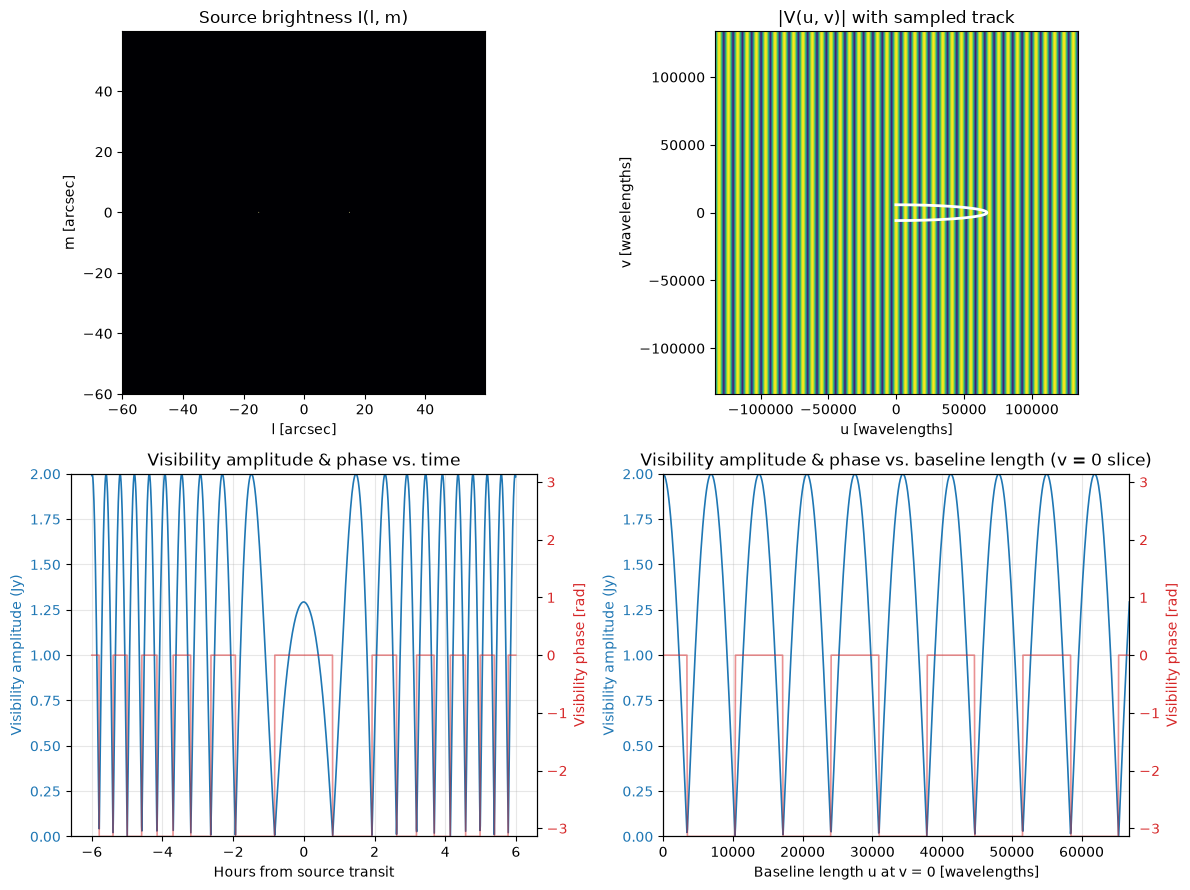

In [ ]:
intensity_double = double_point_source(l, m, dl, separation=30 * u.arcsec, flux_ratio=1.0, point_fwhm=0.1 * u.arcsec, flux=1.0*u.Jy)

results_double = simulate_extended_source_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    source=source,
    frequency=frequency,
    intensity=intensity_double,
    dl=dl,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=12 * u.hour,
    observation_steps=2000,
    pad_factor=12
)

## 8. Sanity check: Gaussian source against the analytic formula

For a circular Gaussian brightness of FWHM `theta`, the visibility amplitude along a 1-D baseline
of `u` wavelengths is `exp(-2 pi^2 sigma^2 u^2)`, with `sigma = theta / (2 sqrt(2 ln 2))`. This
compares the FFT + interpolation result to that closed-form expression at the actual `(u, v)`
track sampled above.

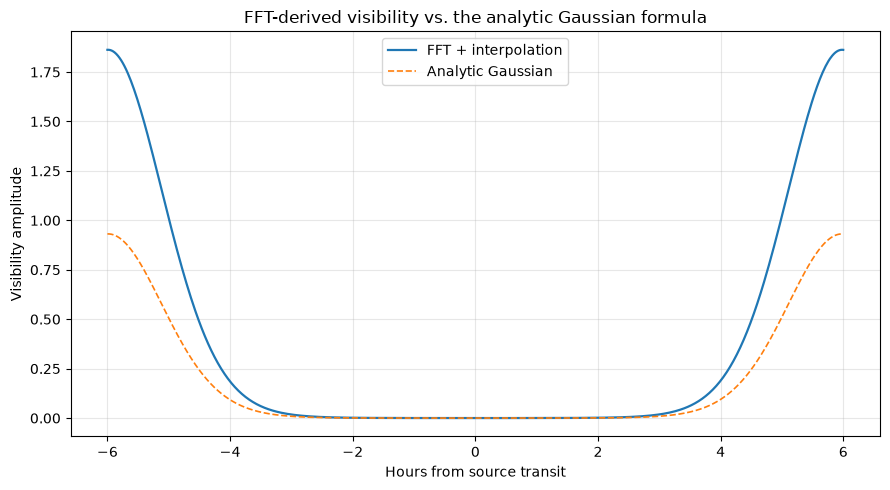

In [119]:
theta_fwhm = 5 * u.arcsec
sigma_rad = theta_fwhm.to(u.rad).value / (2.0 * np.sqrt(2.0 * np.log(2.0)))

u_t, v_t = results_gaussian["u"], results_gaussian["v"]
uv_radius = np.sqrt(u_t ** 2 + v_t ** 2)
analytic_amplitude = np.exp(-2.0 * np.pi ** 2 * sigma_rad ** 2 * uv_radius ** 2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_gaussian["transit_hours"], results_gaussian["visibility_amplitude"], lw=1.6, label="FFT + interpolation")
ax.plot(results_gaussian["transit_hours"], analytic_amplitude, lw=1.2, ls="--", label="Analytic Gaussian")
ax.set_xlabel("Hours from source transit")
ax.set_ylabel("Visibility amplitude")
ax.set_title("FFT-derived visibility vs. the analytic Gaussian formula")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Baseline length = 10021.618 m
Observing wavelength = 0.1499 m
Baseline = 66857.04 wavelengths
Transit time = 2026-09-20 10:11:57.293
Observation centre time = 2026-09-20 10:11:57.293


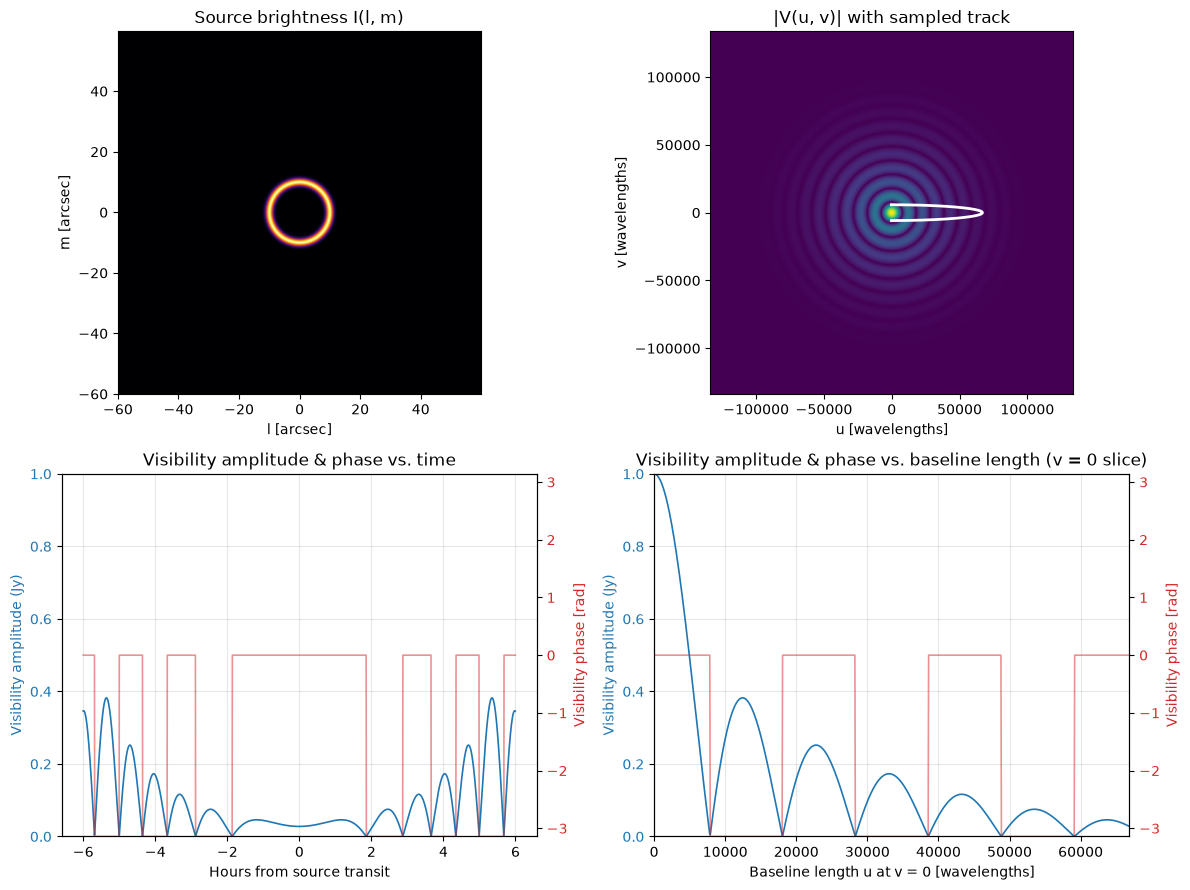

In [120]:
intensity_ring = gaussian_ring_source(l, m, radius=10.0 * u.arcsec, fwhm=2.0 * u.arcsec)
results_ring = simulate_extended_source_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    source=source,
    frequency=frequency,
    intensity=intensity_ring,
    dl=dl,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=12 * u.hour,
    observation_steps=2000,
    pad_factor=12
)

In [121]:
galaxy_intensity = radio_galaxy_source(
    l,
    m,
    separation=30 * u.arcsec,
    lobe_fwhm=10 * u.arcsec,
    core_fwhm=1 * u.arcsec,
    core_flux=100.0,
    lobe_flux_ratio=1.2,
    pa=45 * u.deg,
)
results_galaxy = simulate_extended_source_interferometer(
    antenna_A=antenna_A,
    antenna_B=antenna_B,
    source=source,
    frequency=frequency,
    intensity=galaxy_intensity,
    dl=dl,
    reference_date=reference_date,
    hours_from_transit=hours_from_transit,
    observation_length=12 * u.hour,
    observation_steps=2000,
    pad_factor=12,
    log_intensity=True
)

UnitConversionError: '1 / rad2' and 'Jy / sr' (surface brightness) are not convertible